## Pycaret Notebook 

In [4]:
import pandas as pd
import numpy as np
import shap
from pprint import pprint
from pycaret.classification import *
#from pycaret.classification import interpret_model

In [5]:
df = pd.read_excel(r"C:\Users\LENOVO\Documents\D\Documentos\Javeriana\IX semestre\Analítica 2\Proyecto_Final\data\bank_churn.xlsx")
#df.head()

#### Target mapping
This is done in order to align the binary decision of the attrition_flag: 0: Existing; 1: Attrited

In [6]:
df["attrition_flag"] = df["attrition_flag"].replace({
    "Attrited Customer": 1,
    "Existing Customer": 0
}).astype(int)


## Data Set Up

In [7]:
exp_clf = setup(data = df, target = 'attrition_flag')  # By default, it takes the first column as index and ignores it                                                      # By deafult, it splits the data into 70% train and 30% test

,Description,Value
0,Session id,6049
1,Target,attrition_flag
2,Target type,Binary
3,Original data shape,"(10127, 21)"
4,Transformed data shape,"(10127, 38)"
5,Transformed train set shape,"(7088, 38)"
6,Transformed test set shape,"(3039, 38)"
7,Numeric features,15
8,Categorical features,5
9,Preprocess,True


## Modeling

In [8]:
best_model = compare_models(verbose=False)
results = pull()

numeric_cols = results.select_dtypes(include="number").columns
styled_results = results.style.highlight_max(subset=numeric_cols, color='#5fba7d')
styled_results

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.970900,0.992800,0.885000,0.931800,0.907200,0.890000,0.890800,0.180000
gbc,Gradient Boosting Classifier,0.964200,0.988400,0.838400,0.931900,0.882400,0.861300,0.863200,0.292000
ada,Ada Boost Classifier,0.955400,0.982900,0.831400,0.884400,0.856800,0.830500,0.831200,0.113000
rf,Random Forest Classifier,0.952000,0.985600,0.770800,0.918900,0.837600,0.809700,0.814500,0.184000
dt,Decision Tree Classifier,0.933800,0.876800,0.792800,0.796300,0.794000,0.754600,0.755000,0.045000
et,Extra Trees Classifier,0.922400,0.971800,0.573300,0.911900,0.703200,0.661300,0.685300,0.122000
lda,Linear Discriminant Analysis,0.905600,0.925200,0.612800,0.755300,0.675500,0.621100,0.626400,0.036000
ridge,Ridge Classifier,0.902400,0.925200,0.481100,0.844600,0.612100,0.561200,0.590700,0.037000
qda,Quadratic Discriminant Analysis,0.885600,0.910100,0.724300,0.625500,0.670400,0.601800,0.604700,0.039000
lr,Logistic Regression,0.845900,0.771700,0.093000,0.619300,0.124900,0.104800,0.160400,0.535000


In [9]:
df_ = pd.DataFrame(best_model.get_params().items(), columns=['parameter', 'value'])
df_


,parameter,value
0,boosting_type,gbdt
1,class_weight,None
2,colsample_bytree,1.0
3,importance_type,split
4,learning_rate,0.1
5,max_depth,-1
6,min_child_samples,20
7,min_child_weight,0.001
8,min_split_gain,0.0
9,n_estimators,100


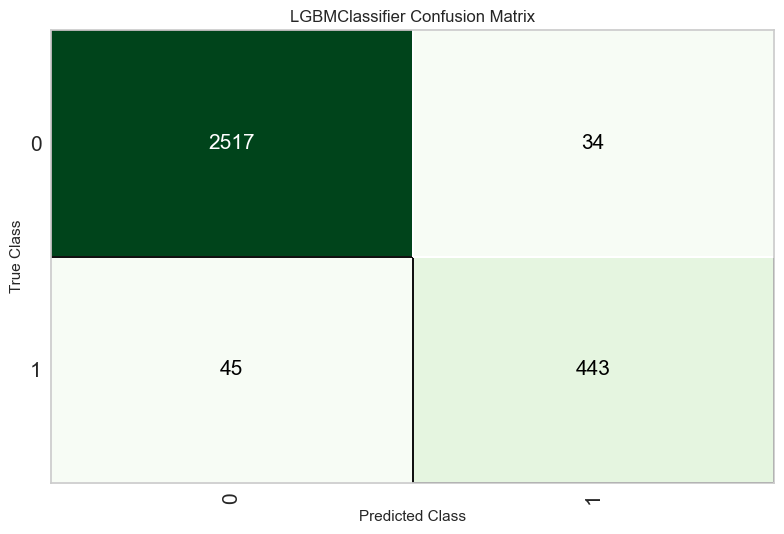

In [10]:
exp_clf.plot_model(best_model, plot = 'confusion_matrix')

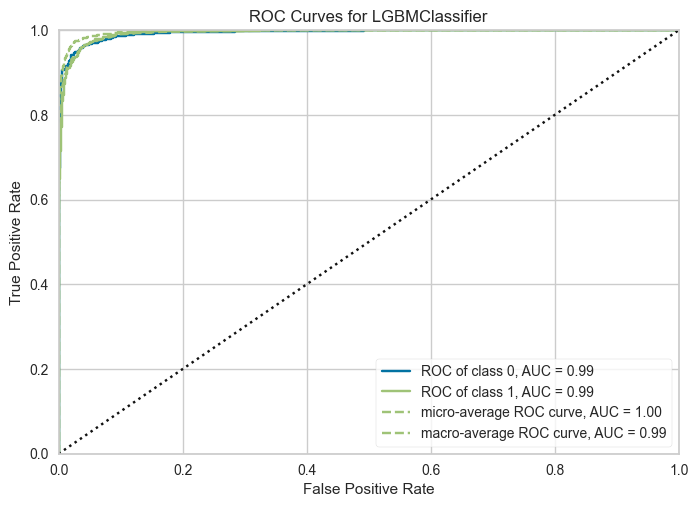

In [11]:
plot_model(best_model, plot = 'auc')

### Model Interpretation


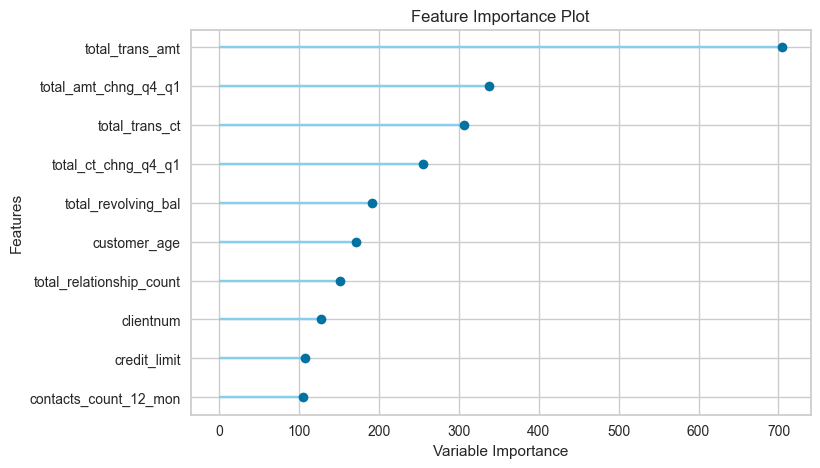

In [12]:
## Feature Importance
feat_imp = plot_model(best_model, plot = 'feature')

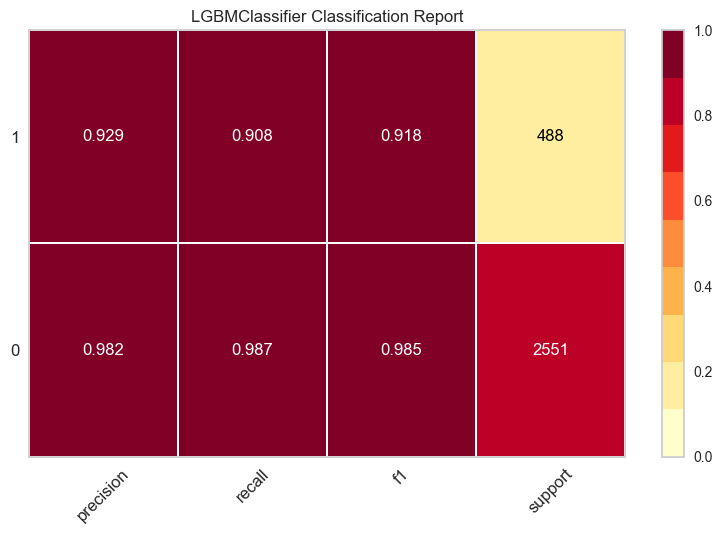

In [13]:
shap_ = plot_model(best_model, plot = 'class_report' )

In [14]:
dashboard(best_model, display_format='inline')

Note: model_output=='probability'. For LGBMClassifier shap values normally get calculated against X_background, but paramater X_background=None, so using X instead
Generating self.shap_explainer = shap.TreeExplainer(model, X, model_output='probability', feature_perturbation='interventional')...
Note: Shap interaction values will not be available. If shap values in probability space are not necessary you can pass model_output='logodds' to get shap values in logodds without the need for a background dataset and also working shap interaction values...
Building ExplainerDashboard..
For this type of model and model_output interactions don't work, so setting shap_interaction=False...
The explainer object has no decision_trees property. so setting decision_trees=False...
Generating layout...
Calculating shap values...


 95%|=================== | 2872/3039 [00:13<00:00]       

Calculating prediction probabilities...
Calculating metrics...
Calculating confusion matrices...
Calculating classification_dfs...
Calculating roc auc curves...
Calculating pr auc curves...
Calculating liftcurve_dfs...
Calculating dependencies...
Calculating permutation importances (if slow, try setting n_jobs parameter)...
Calculating pred_percentiles...
Calculating predictions...
Reminder: you can store the explainer (including calculated dependencies) with explainer.dump('explainer.joblib') and reload with e.g. ClassifierExplainer.from_file('explainer.joblib')
Registering callbacks...
Starting ExplainerDashboard inline (terminate it with ExplainerDashboard.terminate(8050))
